In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import json

In [2]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/new_data_MZB.csv')
df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/ontogeny_counts.csv')


file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/TDM/TDM_T1division_phi.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

/tmp/ipykernel_325223/2599803745.py:17: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


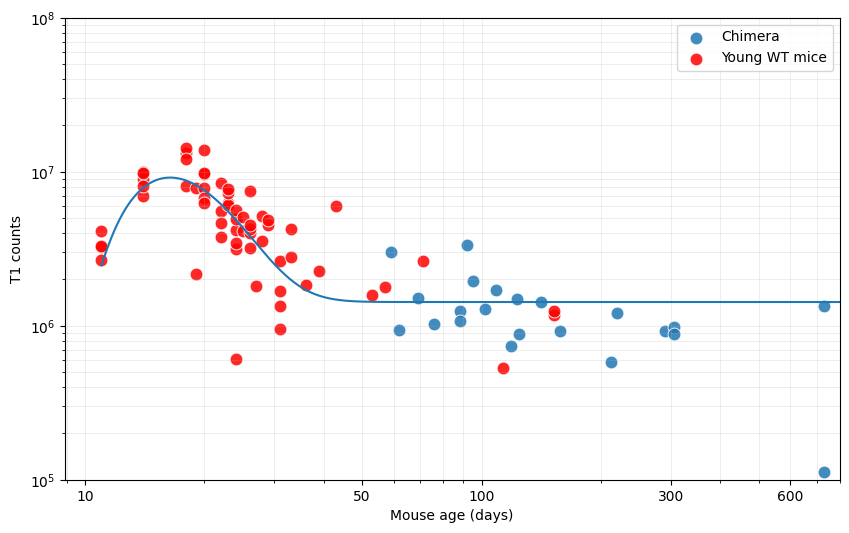

In [3]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    

# Plot T1 AA4.1 counts

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', alpha=0.85 ,s=85, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', alpha=0.85, s=85, color = 'Red',label='Young WT mice', legend=False)
plt.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)))
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 1e8)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 50,  100, 300, 600], [10, 50, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('T1 counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


In [4]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
   
def rho_var(t):
    rho = np.mean(data_neutral.rho)
    r_d = np.mean(data_neutral.r_d)
    rho_var =  rho * np.exp(-r_d * (t-40))
    return rho_var

def lambda_var(t):
    delta = (np.mean(data_neutral.phi) * 1298783) / np.mean(data_neutral.MZ_counts_pred1) # Influx rate
    rho = rho_var(t)
    # lambda_var = (delta - rho)
    lambda_var = delta
    return lambda_var

# Define the ODE function
def ode_function(t, M, phi, lambda_var, P):
    dMdt = phi * P(t) - lambda_var(t) * M
    return dMdt  # Ensure the return value matches the shape of M


# Define the parameters as array

phi = np.mean(data_neutral.phi)  # Influx rate
# delta = np.mean(data_neutral.delta)  #Division rate

# phi = 0.018 #Influx rate
# rho = 0.024 #Division rate
# delta = 0.027 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 731, 0.001)  # Ensure t_ev starts from 40 to match t_span

sol = solve_ivp(ode_function, [11, 731], M0, t_eval=t_ev, args=(phi, lambda_var, P))
print(sol.y)

# sol = np.zeros((len(data_neutral.phi), len(t_ev)))
# for i in range(len(data_neutral.phi)):
#     result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi[i], rho_var, delta[i], P))
#     sol[i, :] = result.y[0][:len(t_ev)]  # Ensure the result matches the shape of sol[i, :]

# print(sol.shape)
# print(M0)



[[  12058.           12094.64007843   12131.3058326  ... 2732039.4154694
  2732039.453953   2732039.49243638]]


/tmp/ipykernel_325223/1980957272.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


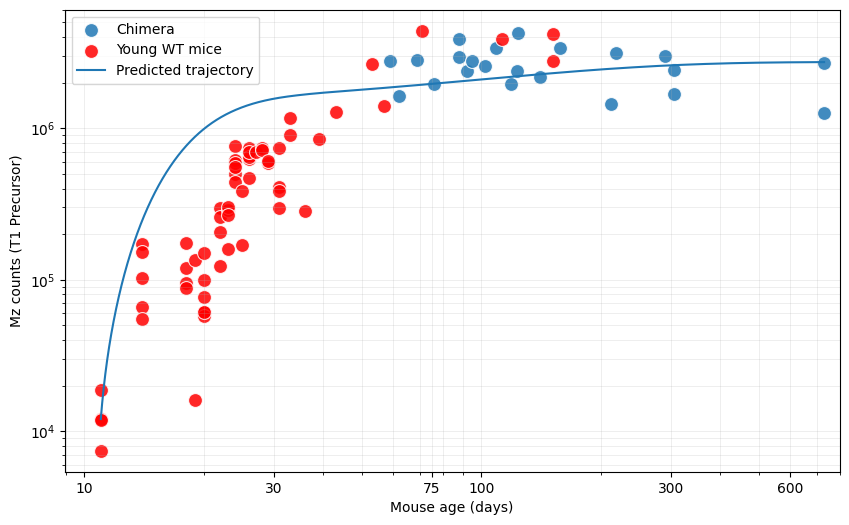

In [5]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
# plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()



In [6]:
def P(t):
    # theta_0 = np.exp(14.17)
    # nu = 0.31
    # n = 1.98
    theta_0 = np.exp(14.12)
    nu = 0.28
    n = 2.1
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi(t):
    r_phi = data_neutral.stan_variable('r_d')  # Extract 'r_d' from CmdStanMCMC object
    phi = data_neutral.stan_variable('phi')  # Extract 'phi' from CmdStanMCMC object
    phi_var = phi / (1 + np.exp(-r_phi * (t - 30)))
    # phi_var = phi * np.exp(-r_phi * (t - 40))
    return phi_var

# Define the ODE function
def ode_function(t, M, phi, rho, delta, P):
    dMdt = phi(t) * P(t) + rho* M - delta * M
    return np.array(dMdt) 


# Define the parameters as array
# lamda = np.mean(data_neutral.delta) - np.mean(data_neutral.rho)
rho = data_neutral.rho
delta = data_neutral.delta
print("rphi", np.mean(data_neutral.r_d))


#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi_values = data_neutral.stan_variable('phi')  # Extract 'phi' values from CmdStanMCMC object
r_phi_values = data_neutral.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object

sol = np.zeros((len(phi_values), len(t_ev)))
for i in range(len(phi_values)):
    def phi_func(t):
        return phi_values[i] / (1 + np.exp(-r_phi_values[i] * (t - 30)))
    
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi_func, rho[i], delta[i], P))
    sol[i, :] = result.y[0]

AttributeError: Unknown variable name: delta
Available variables are y0_Log, kappa_0, sigma, phi, rho, r_d, k_hat, totalMz_mean, Nfd_mean, Kid_mean, Kih_mean, MZ_counts_mean, donor_fractions_mean, host_ki_mean, donor_ki_mean, parms, initial_cond, y0, k_hat_pred1, k_hat_pred2, k_hat_pred3, MZ_counts_pred1, Nfd_pred1, host_ki_pred1, donor_ki_pred1, MZ_counts_pred2, Nfd_pred2, host_ki_pred2, donor_ki_pred2, MZ_counts_pred3, Nfd_pred3, host_ki_pred3, donor_ki_pred3, rho_rate, log_lik_Mz, log_lik_Nfd, log_lik_Kid, log_lik_Kih, residuals_Mz, residuals_Nfd, residuals_Kid, residuals_Kih

In [ ]:
def P(t):
    theta_0 = np.exp(14.12)
    nu = 0.28
    n = 2.1
    # return theta_0 * (1 + (t-11)**n * np.exp(-nu * (t-11)))
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
   
def rho_var(t):
    rho = np.mean(data_neutral.rho)
    r_d = 0.004
    rho_var =  rho * (1 - np.exp(r_d * (t-32)))
    return rho_var

# def phi(t):
#     r_phi = 0.9
#     phi = 0.018
#     phi_var =  ((phi - 0.0011) / (1 + np.exp(-(r_phi) * (t-23)))) +0.0011
#     # phi_var =  phi / (1 + np.exp(-(r_phi) * (t-22)))
#     return phi_var

# Define the ODE function
def ode_function(t, M, phi, rho_var, delta, P):
    dMdt = phi * P(t) + rho_var(t) * M - delta * M
    return dMdt  # Ensure the return value matches the shape of M


# Define the parameters as array

# phi = data_neutral.phi  #Influx rate
# rho = data_neutral.rho  #Division rate

phi = 0.018 #Influx rate
# rho = 0.024 #Division rate
delta = 0.027 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

sol = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi, rho_var, delta, P))
print(sol.y)


[[12058.         12100.567048   12143.1666221  ... 57694.86856772
  57694.62764683 57694.38673091]]


/tmp/ipykernel_326173/2696466209.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


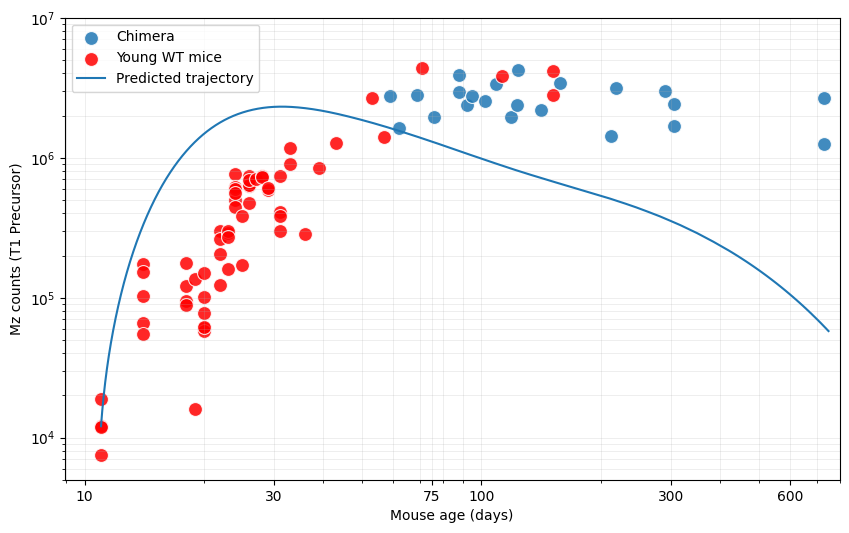

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))


def delta_dd(M):
    delta = 0.00035
    size = 4e4
    delta_dd =  delta * (1 + (M/size))
    return delta_dd

# Define the ODE function
def ode_function(t, M, phi, rho, delta_dd, P):
    dMdt = phi * P(t) + rho * M - delta_dd(M) * M
    return np.array(dMdt)

phi = 0.014 #Influx rate
rho = 0.019  #Division rate
# delta = 0.028 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 160, 0.001)


sol_1 = solve_ivp(ode_function, [11, 160], M0, t_eval=t_ev, args=(phi, rho, delta_dd, P))
print(sol_1.y)
print(np.mean(data_neutral.delta))
print(np.mean(data_neutral.size_dens))

[[  12058.           12092.82940721   12127.68391239 ... 2890782.44600569
  2890783.19496991 2890783.94391084]]
0.02691622406666666


AttributeError: Unknown variable name: size_dens
Available variables are y0_Log, kappa_0, sigma, phi, r_d, rho, delta, k_hat, totalMz_mean, Nfd_mean, Kid_mean, Kih_mean, MZ_counts_mean, donor_fractions_mean, host_ki_mean, donor_ki_mean, parms, initial_cond, y0, k_hat_pred1, k_hat_pred2, k_hat_pred3, MZ_counts_pred1, Nfd_pred1, host_ki_pred1, donor_ki_pred1, MZ_counts_pred2, Nfd_pred2, host_ki_pred2, donor_ki_pred2, MZ_counts_pred3, Nfd_pred3, host_ki_pred3, donor_ki_pred3, delta_inv, log_lik_Mz, log_lik_Nfd, log_lik_Kid, log_lik_Kih, residuals_Mz, residuals_Nfd, residuals_Kid, residuals_Kih

/tmp/ipykernel_3498136/2534866978.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


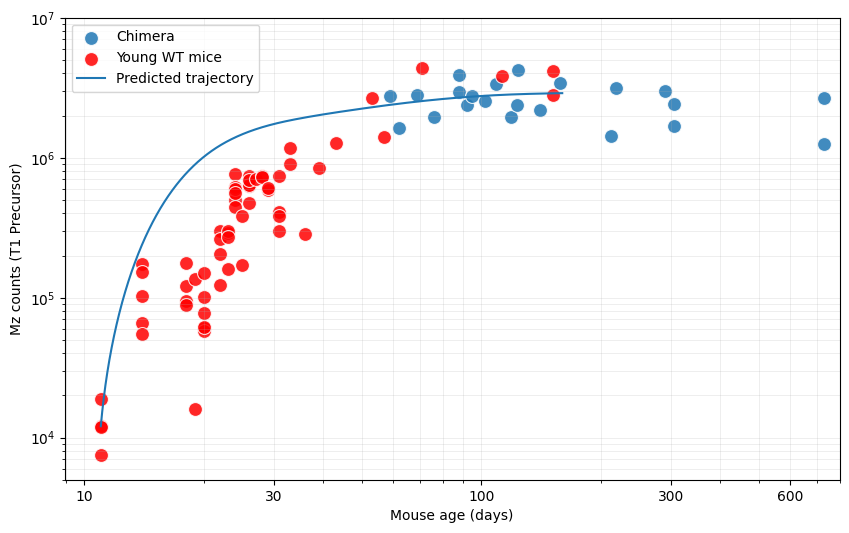

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))


def delta_dd(M):
    delta = 0.009
    size = 33292
    delta_dd =  delta * (1 + (M/size))
    return delta_dd

# Define the ODE function
def ode_function(t, M, phi, rho, delta_dd, P):
    dMdt = phi * P(t) + rho * M - delta_dd(M) * M
    return np.array(dMdt)

phi = 0.014 #Influx rate
rho = 0.019  #Division rate
# delta = 0.028 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 160, 0.001)


sol_1 = solve_ivp(ode_function, [11, 160], M0, t_eval=t_ev, args=(phi, rho, delta_dd, P))
print(sol_1.y)

[[ 12058.          12092.68681142  12127.39819848 ... 290883.10156521
  290883.09289394 290883.08421305]]


/tmp/ipykernel_3498136/2534866978.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


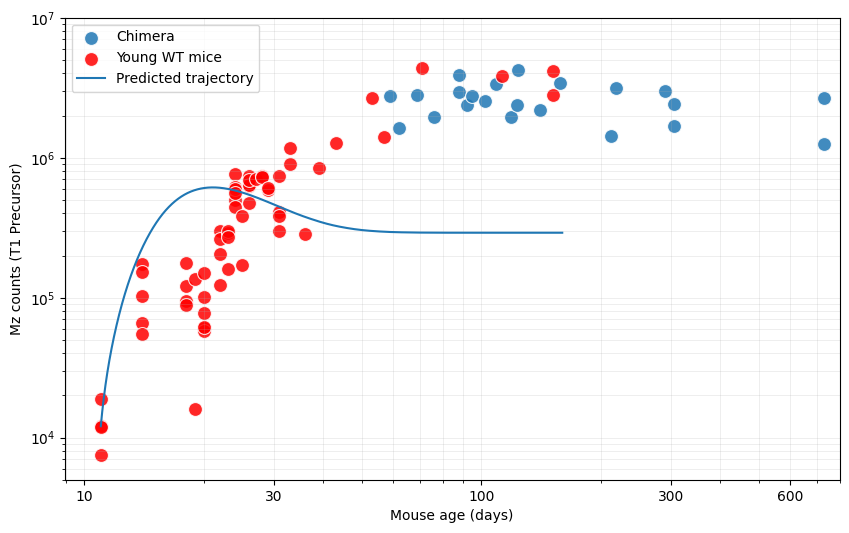

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
def P(t):
    theta_0 = np.exp(14.12)
    nu = 0.29
    n = 2.1
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi(t):
    r_phi = 0.25
    phi = 0.013
    # phi_var =  ((phi - 0.0019) / (1 + np.exp(-(r_phi) * (t-20)))) +0.0019
    phi_var =  phi / (1 + np.exp(-(r_phi) * (t-23)))
    return phi_var

def delta_dd(M):
    delta = np.mean(data_neutral.delta)
    size = np.mean(data_neutral.size_dens)
    delta_dd =  delta * (1 + (M/size))
    return delta_dd

# Define the ODE function
def ode_function(t, M, phi, rho, delta_dd, P):
    dMdt = phi(t) * P(t) + rho * M - delta_dd(M) * M
    return np.array(dMdt)

# def phi(t):
#     if(t < 40):
#     #  r_phi = 0.02
#     #  phi = 0.014
#     #  phi_var =  phi * (1 - np.exp(-(r_phi) * (t-10)**1.7))
#      r_phi = 0.02
#      phi = 0.014
#      phi_var =  phi / (1 + np.exp(-(r_phi) * (t-10)))
#     return(phi_var)


rho = 0.019  #Division rate
# delta = 0.028 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)


sol_1 = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi, rho, delta_dd, P))
print(sol_1.y)
print(np.mean(data_neutral.delta))
print(np.mean(data_neutral.size_dens))

[[  12058.           12059.6856996    12061.37291185 ... 2481743.77845167
  2481743.78669936 2481743.79494843]]
0.00034548063786999994
33291.814297


/tmp/ipykernel_3498136/2960672019.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


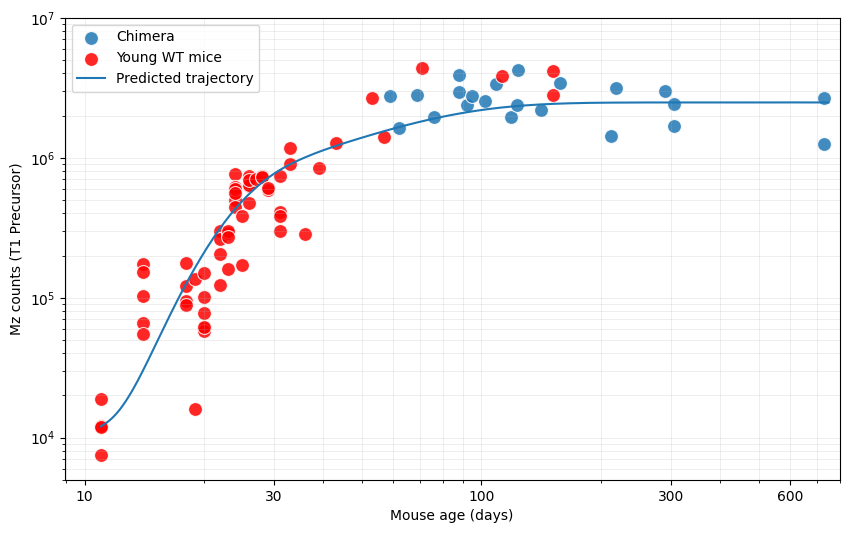

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


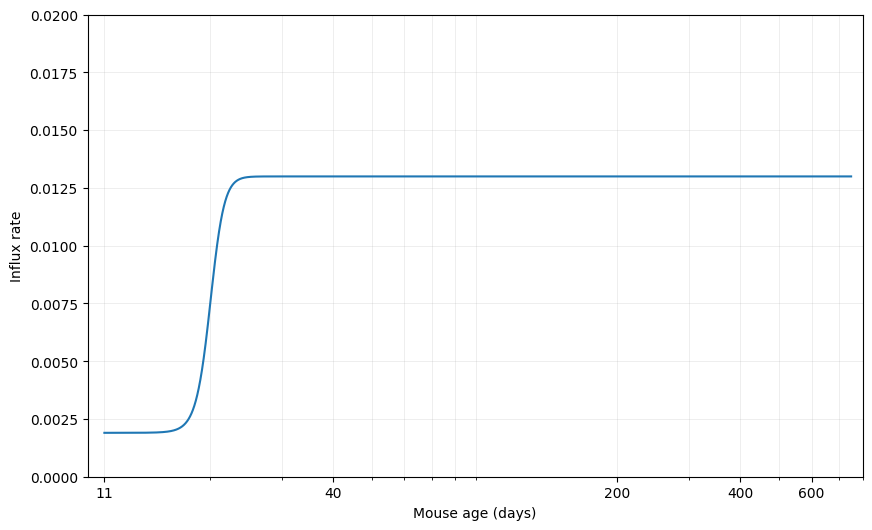

In [ ]:
#Daily Influx from T1 TO Mz
# Plot phi(t)

fig = plt.figure(figsize=(10, 6))
plt.plot(t_ev, phi(t_ev))
plt.xscale('log')
# plt.yscale('log')
plt.xlim(10, 800)
plt.ylim(0, 0.02)
plt.xticks([11, 40, 200, 400, 600], [11, 40, 200, 400, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Influx rate')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.show()

